# 03 - ByteTrack Baseline

Obiettivo:
- caricare il miglior checkpoint RF-DETR Nano fine-tuned;
- eseguire detection frame-by-frame su una sequenza SportsMOT;
- applicare ByteTrack;
- ottenere track_id persistenti;
- generare un video annotato;
- salvare le tracce in formato tabellare.

Questa fase rappresenta la prima baseline di multi-object tracking.

In [47]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
!pip install -q "rfdetr[train,loggers]==1.10.1"
!pip install -q trackers supervision opencv-python

In [49]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import supervision as sv
import matplotlib.pyplot as plt

from rfdetr import RFDETRNano
from trackers import ByteTrackTracker

In [50]:
DRIVE_ROOT = Path("/content/drive/MyDrive/basketball-thesis")

DATASET_ROOT = Path("/content/data/sportsmot_coco")

CHECKPOINT_DIR = DRIVE_ROOT / "checkpoints" / "rfdetr_nano_10epochs"

OUTPUT_DIR = DRIVE_ROOT / "experiments" / "bytetrack_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

print("Checkpoint dir:", CHECKPOINT_DIR)
print("Output dir:", OUTPUT_DIR)

Checkpoint dir: /content/drive/MyDrive/basketball-thesis/checkpoints/rfdetr_nano_10epochs
Output dir: /content/drive/MyDrive/basketball-thesis/experiments/bytetrack_baseline


In [51]:
for f in sorted(CHECKPOINT_DIR.glob("*")):
    print(f.name)

checkpoint_0.ckpt
checkpoint_1.ckpt
checkpoint_2.ckpt
checkpoint_3.ckpt
checkpoint_4.ckpt
checkpoint_5.ckpt
checkpoint_6.ckpt
checkpoint_7.ckpt
checkpoint_8.ckpt
checkpoint_9.ckpt
checkpoint_best_ema.pth
checkpoint_best_total.pth
events.out.tfevents.1790604242.4b3964ec18e0.964.0
events.out.tfevents.1790604468.4b3964ec18e0.964.1
events.out.tfevents.1790705410.0e50ccf2452a.2019.0
events.out.tfevents.1790705727.0e50ccf2452a.2019.1
hparams.yaml
last_ema.pth
metrics.csv
training_config.json


In [52]:
CHECKPOINT_PATH = CHECKPOINT_DIR / "checkpoint_best_total.pth"

print("Checkpoint:", CHECKPOINT_PATH)
print("Esiste:", CHECKPOINT_PATH.exists())

Checkpoint: /content/drive/MyDrive/basketball-thesis/checkpoints/rfdetr_nano_10epochs/checkpoint_best_total.pth
Esiste: True


In [54]:
from pathlib import Path

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

SPORTSMOT_ROOT = Path(
    "/content/drive/MyDrive/basketball-thesis/datasets/sportsmot"
)

SEQUENCE_DIR = (
    SPORTSMOT_ROOT
    / "val"
    / SEQUENCE_NAME
)

FRAMES_DIR = SEQUENCE_DIR / "img1"

print("Sequence:", SEQUENCE_DIR)
print("Sequence exists:", SEQUENCE_DIR.exists())
print("Frames dir:", FRAMES_DIR.exists())
print("GT:", (SEQUENCE_DIR / "gt" / "gt.txt").exists())
print("Seqinfo:", (SEQUENCE_DIR / "seqinfo.ini").exists())

Sequence: /content/drive/MyDrive/basketball-thesis/datasets/sportsmot/val/v_00HRwkvvjtQ_c001
Sequence exists: True
Frames dir: True
GT: True
Seqinfo: True


In [56]:
import configparser

seqinfo_path = SEQUENCE_DIR / "seqinfo.ini"

config = configparser.ConfigParser()
config.read(seqinfo_path)

sequence_info = config["Sequence"]

fps = int(sequence_info["frameRate"])
width = int(sequence_info["imWidth"])
height = int(sequence_info["imHeight"])
seq_length = int(sequence_info["seqLength"])

print("FPS:", fps)
print("Resolution:", width, "x", height)
print("Frames:", seq_length)

FPS: 25
Resolution: 1280 x 720
Frames: 1162


In [55]:
frames = [
    FRAMES_DIR / f"{i:06d}.jpg"
    for i in range(1, seq_length + 1)
]

missing_frames = [
    frame_path
    for frame_path in frames
    if not frame_path.exists()
]

print("Frame attesi:", len(frames))
print("Frame mancanti:", len(missing_frames))

if missing_frames:
    print("Primi frame mancanti:")
    for frame_path in missing_frames[:10]:
        print(frame_path.name)
else:
    print("OK: tutti i frame previsti sono presenti.")

Frame attesi: 1162
Frame mancanti: 0
OK: tutti i frame previsti sono presenti.


Caricamento del checkpoint RF-DETR fine-tuned

In [57]:
model = RFDETRNano(
    pretrain_weights=str(CHECKPOINT_PATH)
)

print("Modello caricato.")

[2026-10-01 15:29:47] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-01 15:29:47] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-01 15:29:49] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.


Modello caricato.


In [58]:
tracker = ByteTrackTracker(
    frame_rate=fps
)

print("ByteTrack inizializzato.")

ByteTrack inizializzato.


In [59]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

Test su pochi frame

In [60]:
test_frames = frames[:30]

track_rows = []

last_frame_bgr = None
last_tracked = None

for frame_index, frame_path in enumerate(test_frames, start=1):

    frame_bgr = cv2.imread(str(frame_path))
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    detections = model.predict(frame_rgb)

    tracked = tracker.update(detections)

    if tracked.tracker_id is not None:
        valid_mask = tracked.tracker_id != -1
        tracked_valid = tracked[valid_mask]
    else:
        tracked_valid = tracked

    last_frame_bgr = frame_bgr.copy()
    last_tracked = tracked_valid

    if tracked_valid.tracker_id is not None:
        for xyxy, confidence, tracker_id in zip(
            tracked_valid.xyxy,
            tracked_valid.confidence,
            tracked_valid.tracker_id,
        ):

            x1, y1, x2, y2 = xyxy

            track_rows.append({
                "frame": frame_index,
                "track_id": int(tracker_id),
                "confidence": float(confidence),
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
            })

print("Track salvate:", len(track_rows))

[2026-10-01 15:29:50] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


Track salvate: 254


Visualizzazione di un frame test

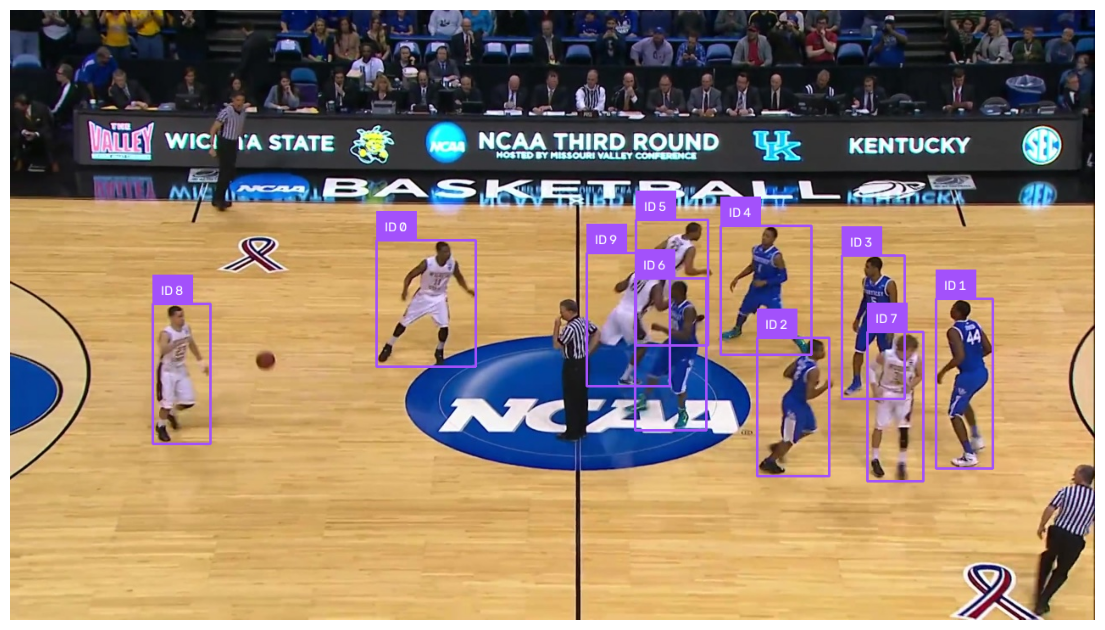

In [61]:
labels = [
    f"ID {int(tracker_id)}"
    for tracker_id in last_tracked.tracker_id
]

annotated = box_annotator.annotate(
    scene=last_frame_bgr.copy(),
    detections=last_tracked,
)

annotated = label_annotator.annotate(
    scene=annotated,
    detections=last_tracked,
    labels=labels,
)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB,
    )
)
plt.axis("off")
plt.show()

Reset tracker prima della run completa

In [62]:
tracker = ByteTrackTracker(
    frame_rate=fps
)

print("Tracker resettato.")

Tracker resettato.


Preparazione video di Output

In [63]:
output_video_path = OUTPUT_DIR / f"{SEQUENCE_NAME}_bytetrack.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(output_video_path),
    fourcc,
    fps,
    (width, height),
)

print(output_video_path)

/content/drive/MyDrive/basketball-thesis/experiments/bytetrack_baseline/v_00HRwkvvjtQ_c001_bytetrack.mp4


Tracking completo della sequenza

In [64]:
track_rows = []

for frame_index, frame_path in enumerate(frames, start=1):

    frame_bgr = cv2.imread(str(frame_path))
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    detections = model.predict(frame_rgb)

    tracked = tracker.update(detections)

    if tracked.tracker_id is not None:
        valid_mask = tracked.tracker_id != -1
        tracked_valid = tracked[valid_mask]
    else:
        tracked_valid = tracked

    labels = []

    if tracked_valid.tracker_id is not None:
        for xyxy, confidence, tracker_id in zip(
            tracked_valid.xyxy,
            tracked_valid.confidence,
            tracked_valid.tracker_id,
        ):

            x1, y1, x2, y2 = xyxy

            track_rows.append({
                "frame": frame_index,
                "time": (frame_index - 1) / fps,
                "track_id": int(tracker_id),
                "confidence": float(confidence),
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
            })

            labels.append(
                f"ID {int(tracker_id)}"
            )

    annotated = box_annotator.annotate(
        scene=frame_bgr.copy(),
        detections=tracked_valid,
    )

    annotated = label_annotator.annotate(
        scene=annotated,
        detections=tracked_valid,
        labels=labels,
    )

    writer.write(annotated)

writer.release()

print("Video completato:", output_video_path)

Video completato: /content/drive/MyDrive/basketball-thesis/experiments/bytetrack_baseline/v_00HRwkvvjtQ_c001_bytetrack.mp4


## Creazione DataFrame delle tracce

In [65]:
tracks_df = pd.DataFrame(track_rows)

print("Numero righe:", len(tracks_df))
print("Numero track ID:", tracks_df["track_id"].nunique())

tracks_df.head()

Numero righe: 10911
Numero track ID: 27


,frame,time,track_id,confidence,x1,y1,x2,y2
0,2,0.04,0,0.946324,434.150208,268.251007,560.730225,436.969055
1,2,0.04,1,0.918906,973.851013,390.865112,1050.417969,604.696655
2,2,0.04,2,0.847886,636.885437,416.111542,768.735291,625.620422
3,2,0.04,3,0.852696,990.499023,290.476685,1053.694336,497.540070
4,2,0.04,4,0.760169,652.945557,272.642029,758.719788,433.214172


Salvataggio CSV

In [66]:
tracks_csv_path = OUTPUT_DIR / f"{SEQUENCE_NAME}_tracks.csv"

tracks_df.to_csv(
    tracks_csv_path,
    index=False,
)

print("CSV salvato:", tracks_csv_path)

CSV salvato: /content/drive/MyDrive/basketball-thesis/experiments/bytetrack_baseline/v_00HRwkvvjtQ_c001_tracks.csv


Statistiche preliminari

In [67]:
track_stats = (
    tracks_df
    .groupby("track_id")
    .agg(
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        detections=("frame", "count"),
        mean_confidence=("confidence", "mean"),
    )
    .sort_values("detections", ascending=False)
)

track_stats.head(20)

,first_frame,last_frame,detections,mean_confidence
track_id,,,,
0,2,1162,1151,0.873700
4,2,1162,1144,0.868595
11,112,1162,1035,0.836224
14,134,1162,971,0.815034
6,3,909,896,0.856967
15,266,1162,886,0.876146
8,17,827,807,0.881087
1,2,818,780,0.854399
13,125,659,509,0.816543


Durata delle tracce

In [68]:
track_stats["duration_frames"] = (
    track_stats["last_frame"]
    - track_stats["first_frame"]
    + 1
)

track_stats["duration_seconds"] = (
    track_stats["duration_frames"] / fps
)

track_stats.head(20)

,first_frame,last_frame,detections,mean_confidence,duration_frames,duration_seconds
track_id,,,,,,
0,2,1162,1151,0.873700,1161,46.44
4,2,1162,1144,0.868595,1161,46.44
11,112,1162,1035,0.836224,1051,42.04
14,134,1162,971,0.815034,1029,41.16
6,3,909,896,0.856967,907,36.28
15,266,1162,886,0.876146,897,35.88
8,17,827,807,0.881087,811,32.44
1,2,818,780,0.854399,817,32.68
13,125,659,509,0.816543,535,21.40


## Distribuzione della durata delle tracce

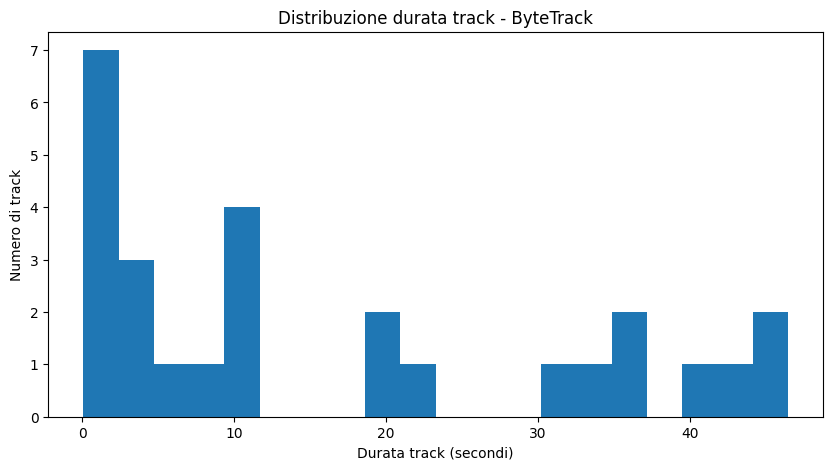

In [69]:
plt.figure(figsize=(10, 5))

plt.hist(
    track_stats["duration_seconds"],
    bins=20,
)

plt.xlabel("Durata track (secondi)")
plt.ylabel("Numero di track")
plt.title("Distribuzione durata track - ByteTrack")

plt.show()

# Risultati baseline ByteTrack

La pipeline composta da RF-DETR Nano fine-tuned e ByteTrack è stata applicata alla sequenza SportsMOT selezionata con l'obiettivo di ottenere identità persistenti dei giocatori nel tempo.

La sequenza utilizzata è:

`v_00HRwkvvjtQ_c001`

Le caratteristiche principali della sequenza sono:

- frame rate: 25 FPS;
- risoluzione: 1280 × 720;
- numero totale di frame: 1162.

Durante l'elaborazione, RF-DETR Nano produce le bounding box dei giocatori presenti in ciascun frame, mentre ByteTrack associa temporalmente le detection appartenenti allo stesso soggetto assegnando un identificatore persistente (`track_id`).

Per ogni osservazione vengono salvate le seguenti informazioni:

- frame;
- timestamp;
- track ID;
- confidence;
- coordinate della bounding box `(x1, y1, x2, y2)`.

## Risultati preliminari

Da aggiornare dopo l'esecuzione definitiva su GPU T4:

- numero totale di osservazioni tracciate:
- numero totale di track ID:
- durata media delle track:
- durata massima delle track:
- numero di track molto brevi:
- eventuali ID switch visibili:
- eventuali frammentazioni osservate:
- presenza di track spurie:
- qualità visiva complessiva del tracking:

È importante sottolineare che il numero totale di `track_id` non corrisponde necessariamente al numero reale di giocatori presenti nella sequenza.

ByteTrack può infatti generare una nuova identità quando una traccia viene persa e successivamente ricreata. Un numero elevato di track ID può quindi essere dovuto a:

- ingressi e uscite dall'inquadratura;
- occlusioni;
- detection mancanti;
- frammentazione delle tracce;
- ID switch;
- associazioni temporali non corrette.

La sola durata di una traccia non è sufficiente per stabilirne la correttezza. Una track molto lunga può infatti contenere uno o più ID switch, mentre una track breve può essere perfettamente corretta se il giocatore compare nell'inquadratura solo per un intervallo limitato.

## Analisi qualitativa

Questa fase rappresenta una baseline qualitativa del sistema di Multi-Object Tracking.

L'analisi visiva del video annotato permette di osservare:

- stabilità dei track ID;
- comportamento durante le occlusioni;
- mantenimento dell'identità durante gli incroci tra giocatori;
- perdita e successiva ricreazione delle tracce;
- eventuali false detection;
- eventuali associazioni errate.

Tali osservazioni consentono di individuare i principali failure mode del sistema, ma non forniscono ancora una misura quantitativa della qualità del tracking.

## Valutazione quantitativa

La valutazione quantitativa verrà effettuata nel notebook successivo, confrontando le predizioni prodotte da ByteTrack con i `track_id` ground truth di SportsMOT.

Verranno utilizzate metriche standard per il Multi-Object Tracking, tra cui:

- HOTA;
- DetA;
- AssA;
- IDF1;
- MOTA;
- ID switches;
- fragmentation.

In particolare, la separazione tra componente di detection e componente di association permetterà di comprendere se gli eventuali errori siano dovuti principalmente al detector RF-DETR oppure al processo di associazione temporale eseguito da ByteTrack.

## Conclusione

L'obiettivo di questo notebook è verificare che la pipeline:

RF-DETR Nano
→ player detection
→ ByteTrack
→ track ID persistenti

sia correttamente funzionante e produca output temporali utilizzabili nelle fasi successive.

Il passo successivo consiste nella valutazione quantitativa delle tracce attraverso il notebook:

`04_tracking_evaluation.ipynb`

I risultati di tale valutazione verranno utilizzati per stabilire se la combinazione RF-DETR Nano + ByteTrack sia sufficientemente stabile per le successive fasi di player localization e ricostruzione delle traiettorie.